This notebook demonstrates the principles of the electric field conjugation algorithm as presented in <a href="https://ui.adsabs.harvard.edu/abs/2007SPIE.6691E..0AG/abstract">Give'on et al. 2007</a>.

# IMPORTS

In [1]:
import numpy as np
from numpy.fft import fft2, ifft2, fftfreq, fftshift
# import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import astropy.units as u
import aotools
# import scipy
# from scipy.signal import argrelextrema

# SETUP

### PROBLEM
Wavefront aberrations require correction for deep nulls with high contrast imaging. Adaptive optics (AO) is limited by (<a href="https://ui.adsabs.harvard.edu/abs/2007SPIE.6691E..0AG/abstract">Give'on et al. 2007</a>):

1. Accuracy of wavefront phase estimation/phase reconstruction. <br>
2. Ability of deformable mirror (DM) to acheive arbitrary shapes.

The latter is out of my hands, so we will address the former instead.


_<b>WAVEFRONT RECONSTRUCTION:</b>_ given a coherent reference wave and its light diffracted by an object, one can extract information about both the amplitude and phase of the diffracted waves even though a detector responds only to intensity ("Introduction to Fourier Optics", Goodman 1968). Wavefront reconstruction consists of two distinct operations:

1. Information-storage operation.
2. Final reconstruction operation.

Recording phase information requires converting it to intensity variations, e.g. interferometry.

_<b>ELECTRIC FIELD CONJUGATION (EFC):</b>_ "a nonlinear optimization procedure that uses measurements of the electric field at the image to determine the DM displacements that modify the PSF to create the region of high contrast in the image" (<a href="https://www.spiedigitallibrary.org/conference-proceedings-of-spie/10400/104000P/Electric-field-conjugation-in-the-presence-of-model-uncertainty/10.1117/12.2274541.full?SSO=1#:~:text=Electric%20field%20conjugation%20(EFC)%20is,high%20contrast%20in%20the%20image.">Marx et al. 2017</a>). EFC requires accurate measurements of the image plane electric field and a good model of the (linear) effect of the DM on the image planet electric field. The goal of EFC is to set the DM to superpose the negative of the electric field onto the image plane, yielding zero image intensity.

### DEFINE OBJECT PLANE

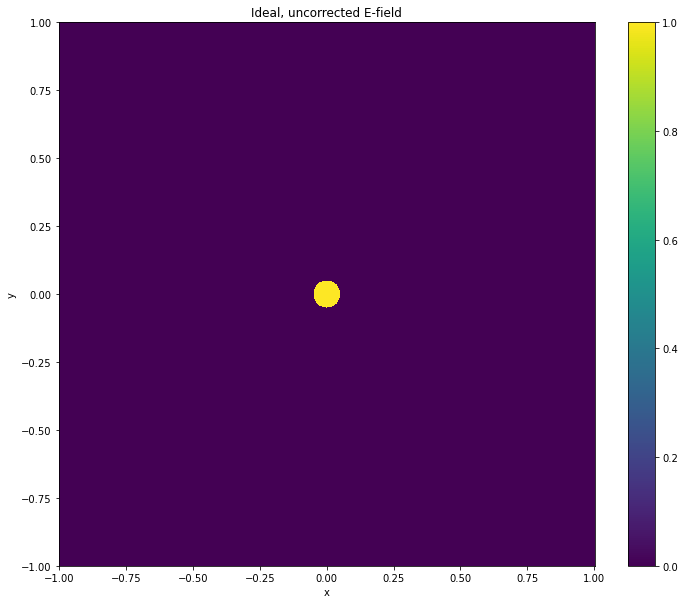

In [2]:
# Define spatial sampling
samples = 1000
pupil_ratio = 0.05
x_samples = np.linspace(-1, 1, samples+1) * u.cm
y_samples = np.copy(x_samples)
x, y = np.meshgrid(x_samples, x_samples) # Spatial grid

# Define ideal, uncorrected electric field
A = np.zeros((samples+1, samples+1)) 
A[(x**2 + y**2) < pupil_ratio**2 * u.cm**2] = 1 # Circular aperture

# Define amplitude/phase contributions from aberrations and DM
A_aber = lambda alpha, beta: np.exp(alpha + 1j*beta) # Aberrations
A_DM = lambda phi: np.exp(1j * phi) # DM

# Define electric field transformation from object to image plane
def C(U, x_samples, y_samples, return_freq=False):
    ''' Transforms electric field from object to image plane
        Inputs:
        - U: numpy 2D array of electric field in object plane
        - x_samples, y_samples: numpy 1D arrays of x/y-values being sampled
        - return_freq: returns FFT frequencies when True
        Outputs:
        - I: numpy 2D array of electric field in image planet
        - X, Y: numpy 2D arrays of x/y frequencies being sampled; only returned when return_freq=True
    '''
    dx, dy = np.diff(x_samples)[0], np.diff(y_samples)[0]
    X = np.fft.fftshift(np.fft.fftfreq(len(x_samples), d=dx))
    Y = np.fft.fftshift(np.fft.fftfreq(len(y_samples), d=dx))
    I = np.fft.fft2(np.fft.ifftshift(U)) # shift zero frequency component to center of spectrum
    I = np.fft.fftshift(I) # shift back
    if return_freq:
        return I, X, Y
    else:
        return I
    
# Show ideal, uncorrected aperture
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
vrange = [np.min(np.absolute(A)), np.max(np.absolute(A))]
im = ax.pcolormesh(x.value, y.value, np.absolute(A), vmin=vrange[0], vmax=vrange[1])
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Ideal, uncorrected E-field')
fig.colorbar(im, ax=ax)
plt.show()

# ELECTRIC FIELD RECONSTRUCTION

The EFC algorithm assumes the aberrations are linear perturbations in phase (and amplitude but we are ignoring that for our purposes). The real (amplitude) and imaginary (phase) components of the electric field are the unknowns we are trying to measure. We can measure both by taking difference image pairs with DM conjugate configuration pairs since the linear response to the DM is known and the resulting images are measured. Since there are two unknowns, we need at least two difference image pairs to solve for both.

### DEMONSTRATE EFC

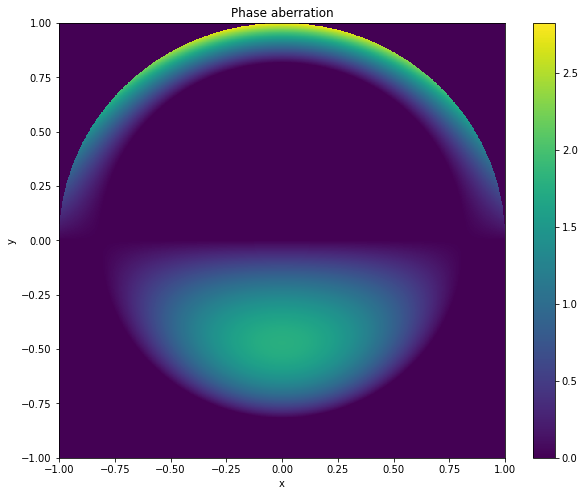

/home/paiasnodkar.1/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:54: RuntimeWarning: invalid value encountered in true_divide
/home/paiasnodkar.1/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:55: RuntimeWarning: invalid value encountered in true_divide


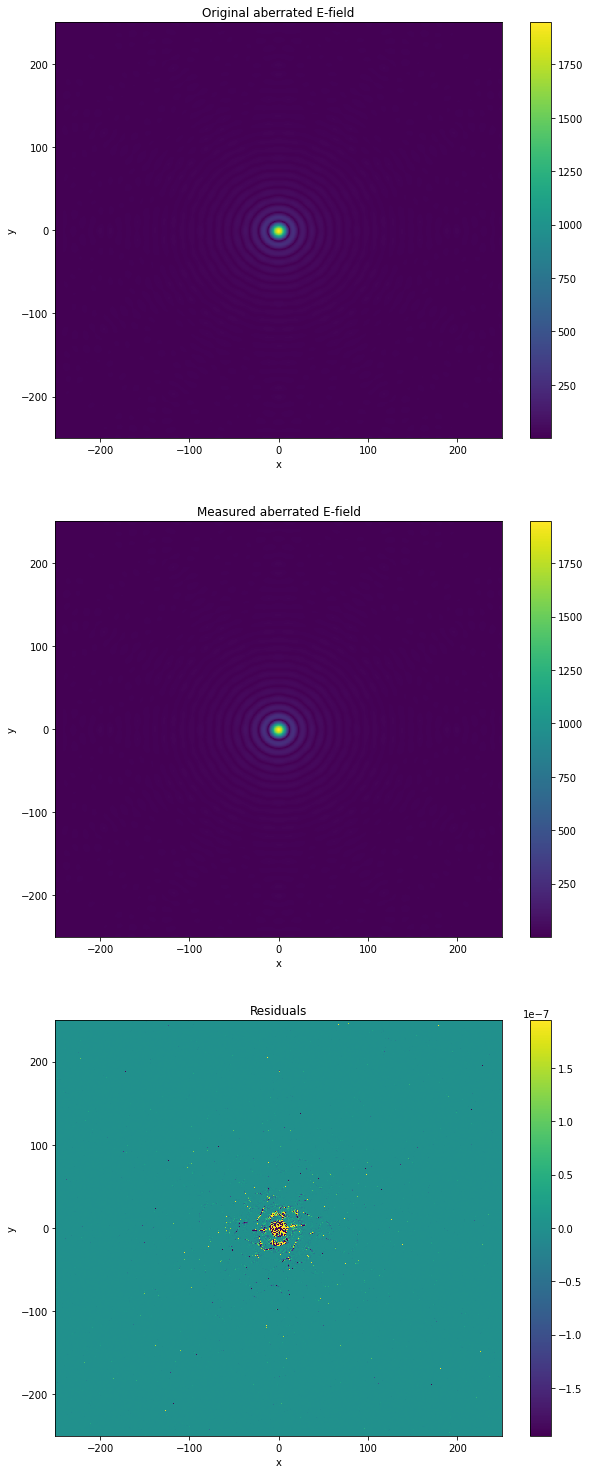

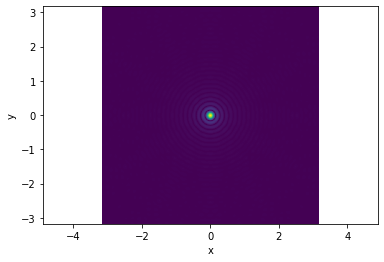

In [23]:
# Define electric field with aberrations
# aberration_factor = 1e-1
alpha, beta = np.zeros_like(A), np.zeros_like(A)
n, m = 3, -1
beta = aotools.functions.zernike.zernike_nm(n, m, samples+1)
E_ab, X, Y = C(A * A_aber(alpha, beta), x_samples, y_samples, return_freq=True)

# Show aberration:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
vrange = [np.min(np.absolute(beta)), np.max(np.absolute(beta))]
im = ax.pcolormesh(x.value, y.value, beta, vmin=vrange[0], vmax=vrange[1])
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Phase aberration')
fig.colorbar(im, ax=ax)
plt.show()

# Define intensity distribution from electric field
I = lambda E: np.absolute(E)**2

# Define calculation of difference images from positive and negative DM configurations
def DM_image_diff(psi_pos, E_ab, A, x_samples, y_samples):
    ''' Computes difference image for a given DM configuration and known electric field,
        with and without aberrations.
        Inputs:
        - psi_pos: numpy 2D array of DM configuration (array of phases)
        - E_ab: numpy 2D array of electric field in image plane with aberrations
        - A: numpy 2D array of electric field in object plane without aberrations
        - x_samples, y_samples: numpy 1D array of x/y-values being sampled
        Outputs:
        - I_diff: numpy 2D array of difference image
        - DM_real, DM_imag: numpy 2D array of real/imaginary component of wavefront response to DM configuration 
        corresponding to the difference image
    '''
    psi_neg = -psi_pos
    E_k_pos = E_ab + 1j * C(A*psi_pos, x_samples, y_samples)
    E_k_neg = E_ab + 1j * C(A*psi_neg, x_samples, y_samples)
    I_diff = I(E_k_pos) - I(E_k_neg)
    DM, X_samples, Y_samples = C(A*psi_pos, x_samples, y_samples, return_freq=True)
    DM = 1j * DM
    DM_real, DM_imag = np.real(DM), np.imag(DM)
    return I_diff, DM_real, DM_imag, X_samples, Y_samples

def EFC(I_diff_1, DM_real_1, DM_imag_1, I_diff_2, DM_real_2, DM_imag_2):
    ''' Computes real and imaginary components of electric field being measured with two pairs of 
        difference images and their corresponding DM responses.
        Inputs:
        - I_diff_1, I_diff_2: numpy 2D arrays of difference images
        - DM_real_1, DM_real_2, DM_imag_1, DM_imag 2: numpy 2D arrays of real/imaginary component of 
        wavefront response to the DM configurations corresponding to the difference images
        Outputs:
        - E_ab_real, E_ab_imag: numpy 2D arrays of real and imaginary component of measured electric field
    '''
    E_ab_imag_num = I_diff_2 - ((DM_real_2 * I_diff_1)/DM_real_1)
    E_ab_imag_denom = DM_imag_2 - ((DM_real_2 * DM_imag_1)/DM_real_1)
    E_ab_imag = E_ab_imag_num/E_ab_imag_denom
    E_ab_real = (I_diff_1 - (DM_imag_1 * E_ab_imag))/DM_real_1
    return 0.25*E_ab_real, 0.25*E_ab_imag

# Define DM configurations
DM_factor = 1e-6
psi_1, psi_2 = np.random.rand(*np.shape(A)) * 2*np.pi * DM_factor, np.random.rand(*np.shape(A)) * 2*np.pi * DM_factor

# Generate corresponding difference images
I_diff_1, DM_real_1, DM_imag_1, X_samples, Y_samples = DM_image_diff(psi_1, E_ab, A, x_samples, y_samples)
I_diff_2, DM_real_2, DM_imag_2, X_samples, Y_samples = DM_image_diff(psi_2, E_ab, A, x_samples, y_samples)
X_samples, Y_samples = (X_samples * (wav_0 * d)).to(u.mm), (Y_samples * (wav_0 * d)).to(u.mm)

# Conduct EFC
E_ab_real, E_ab_imag = EFC(I_diff_1, DM_real_1, DM_imag_1, I_diff_2, DM_real_2, DM_imag_2)
E_ab_EFC = E_ab_real + 1j*E_ab_imag

vrange=[0, 1]
fig, ax = plt.subplots(3, 1, figsize=(10, 26))
vrange = [np.min(np.absolute(E_ab)), np.max(np.absolute(E_ab))]
im = ax[0].pcolormesh(X.value, Y.value, np.absolute(E_ab), vmin=vrange[0], vmax=vrange[1])
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')
ax[0].set_title('Original aberrated E-field')
fig.colorbar(im, ax=ax[0])

im = ax[1].pcolormesh(X.value, Y.value, np.absolute(E_ab_EFC), vmin=vrange[0], vmax=vrange[1])
ax[1].set_xlabel('x')
ax[1].set_ylabel('y')
ax[1].set_title('Measured aberrated E-field')
fig.colorbar(im, ax=ax[1])

residuals = np.absolute(E_ab)-np.absolute(E_ab_EFC)
residuals_factor = 1e-10
im = ax[2].pcolormesh(X.value, Y.value, residuals, vmin=-vrange[1]*residuals_factor, 
                      vmax=vrange[1]*residuals_factor)
ax[2].set_xlabel('x')
ax[2].set_ylabel('y')
ax[2].set_title('Residuals')
fig.colorbar(im, ax=ax[2])

plt.show()


fig = plt.figure()
plt.pcolormesh(X_samples.value, Y_samples.value, np.absolute(E_ab_EFC))
plt.xlim(-cam_x.value/2, cam_x.value/2)
plt.ylim(-cam_y.value/2, cam_y.value/2)
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.show()

### SOLVE FOR WAVEFRONT CORRECTION

# Functions

In [2]:
# Define amplitude/phase contributions from aberrations and DM
A_aber = lambda alpha, beta: np.exp(alpha + 1j*beta) # Aberrations
A_DM = lambda phi: np.exp(1j * phi) # DM

# Define intensity distribution from electric field
I = lambda E: np.absolute(E)**2

# Define electric field transformation from object to image plane
def C(U, x_samples, y_samples, return_freq=False):
    ''' Transforms electric field from object to image plane
        Inputs:
        - U: numpy 2D array of electric field in object plane
        - x_samples, y_samples: numpy 1D arrays of x/y-values being sampled
        - return_freq: returns FFT frequencies when True
        Outputs:
        - I: numpy 2D array of electric field in image planet
        - X, Y: numpy 2D arrays of x/y frequencies being sampled; only returned when return_freq=True
    '''
    dx, dy = np.diff(x_samples)[0], np.diff(y_samples)[0]
    X = np.fft.fftshift(np.fft.fftfreq(len(x_samples), d=dx))
    Y = np.fft.fftshift(np.fft.fftfreq(len(y_samples), d=dx))
    I = np.fft.fft2(np.fft.ifftshift(U)) # shift zero frequency component to center of spectrum
    I = np.fft.fftshift(I) # shift back
    if return_freq:
        return I, X, Y
    else:
        return I
    
# Define calculation of difference images from positive and negative DM configurations
def DM_image_diff(psi_pos, E_ab, A, x_samples, y_samples):
    ''' Computes difference image for a given DM configuration and known electric field,
        with and without aberrations.
        Inputs:
        - psi_pos: numpy 2D array of DM configuration (array of phases)
        - E_ab: numpy 2D array of electric field in image plane with aberrations
        - A: numpy 2D array of electric field in object plane without aberrations
        - x_samples, y_samples: numpy 1D array of x/y-values being sampled
        Outputs:
        - I_diff: numpy 2D array of difference image
        - DM_real, DM_imag: numpy 2D array of real/imaginary component of wavefront response to DM configuration 
        corresponding to the difference image
    '''
    psi_neg = -psi_pos
    E_k_pos = E_ab + 1j * C(A*psi_pos, x_samples, y_samples)
    E_k_neg = E_ab + 1j * C(A*psi_neg, x_samples, y_samples)
    I_diff = I(E_k_pos) - I(E_k_neg)
    DM, X_samples, Y_samples = C(A*psi_pos, x_samples, y_samples, return_freq=True)
    DM = 1j * DM
    DM_real, DM_imag = np.real(DM), np.imag(DM)
    return I_diff, DM_real, DM_imag, X_samples, Y_samples

# Perform EFC for wavefront sensing
def EFC(I_diff_1, DM_real_1, DM_imag_1, I_diff_2, DM_real_2, DM_imag_2):
    ''' Computes real and imaginary components of electric field being measured with two pairs of 
        difference images and their corresponding DM responses.
        Inputs:
        - I_diff_1, I_diff_2: numpy 2D arrays of difference images
        - DM_real_1, DM_real_2, DM_imag_1, DM_imag 2: numpy 2D arrays of real/imaginary component of 
        wavefront response to the DM configurations corresponding to the difference images
        Outputs:
        - E_ab_real, E_ab_imag: numpy 2D arrays of real and imaginary component of measured electric field
    '''
    E_ab_imag_num = I_diff_2 - ((DM_real_2 * I_diff_1)/DM_real_1)
    E_ab_imag_denom = DM_imag_2 - ((DM_real_2 * DM_imag_1)/DM_real_1)
    E_ab_imag = E_ab_imag_num/E_ab_imag_denom
    E_ab_real = (I_diff_1 - (DM_imag_1 * E_ab_imag))/DM_real_1
    return 0.25*E_ab_real, 0.25*E_ab_imag

# Set up system

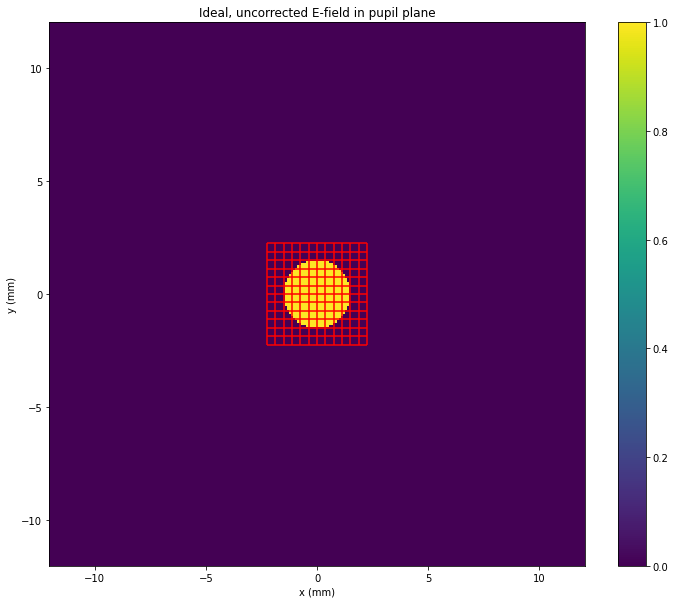

In [5]:
# System properties
f = 100 * u.mm # focal length
d = 200 * u.mm # distance between lens and image
wav_0 = 635 * u.nm # laser beam wavelength
DM_dim_x, DM_dim_y = 4.5 * u.mm, 4.5 * u.mm # width and height of deformable mirror in mm
DM_num_x, DM_num_y = 12, 12 # number of actuators along width and height of deformable mirror
DM_act_x, DM_act_y = DM_dim_x/DM_num_x, DM_dim_y/DM_num_y # actuator size in mm
DM_stroke = 1.5 * u.micron # maximum physical range of DM actuators
cam_dim_x, cam_dim_y = 4.76 * u.mm, 3.57 * u.mm # width and height of detector
cam_num_x, cam_num_y = 1024, 768 # number of pixels along width and height of camera
beam_diam = 3 * u.mm; beam_rad = beam_diam/2.

# Set up pupil plane
N = 2**8
actuator_sample = 4
pupil_dim_x, pupil_dim_y = DM_act_x*N/actuator_sample, DM_act_y*N/actuator_sample
pupil_x, pupil_y = (DM_act_x/actuator_sample)*np.linspace(-N/2, N/2, N+1), (DM_act_y/actuator_sample)*np.linspace(-N/2, N/2, N+1)
pupil_grid_x, pupil_grid_y = np.meshgrid(pupil_x, pupil_y)
DM_pixels_x, DM_pixels_y = actuator_sample*DM_num_x, actuator_sample*DM_num_y
DM_edges_x = np.arange(-DM_dim_x.value/2, DM_dim_x.value/2 + DM_act_x.value, DM_act_x.value) * u.mm
DM_edges_y = np.arange(-DM_dim_y.value/2, DM_dim_y.value/2 + DM_act_y.value, DM_act_y.value) * u.mm
pupil_mid = int(N/2 + 1)
A = np.zeros((N+1, N+1))
A[(pupil_grid_x**2 + pupil_grid_y**2) < beam_rad**2] = 1 # Circular aperture

# Set up camera in image plane
cam_el_x, cam_el_y = cam_dim_x/cam_num_x, cam_dim_y/cam_num_y # camera pixel size in mm
cam_edges_x = np.arange(-cam_dim_x.value/2, cam_dim_x.value/2 + cam_el_x.value, cam_el_x.value) * u.mm
cam_edges_y = np.arange(-cam_dim_y.value/2, cam_dim_y.value/2 + cam_el_y.value, cam_el_y.value) * u.mm

# Define aberrations
# alpha = np.zeros_like(A)
# aberration_factor = 1e-1
# beta = aberration_factor * np.random.rand(DM_num_x, DM_num_y)
# n, m = 3, -1
# beta = aotools.functions.zernike.zernike_nm(n, m, DM_num_x)

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
vrange = [np.min(np.absolute(A)), np.max(np.absolute(A))]
im = ax.pcolormesh(pupil_x.value, pupil_y.value, np.absolute(A), vmin=vrange[0], vmax=vrange[1])
ax.hlines(DM_edges_y.value, -DM_dim_x.value/2, DM_dim_x.value/2, color='r')
ax.vlines(DM_edges_x.value, -DM_dim_y.value/2, DM_dim_y.value/2, color='r')
ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_title('Ideal, uncorrected E-field in pupil plane')
fig.colorbar(im, ax=ax)
plt.show()

In [ ]:
roow

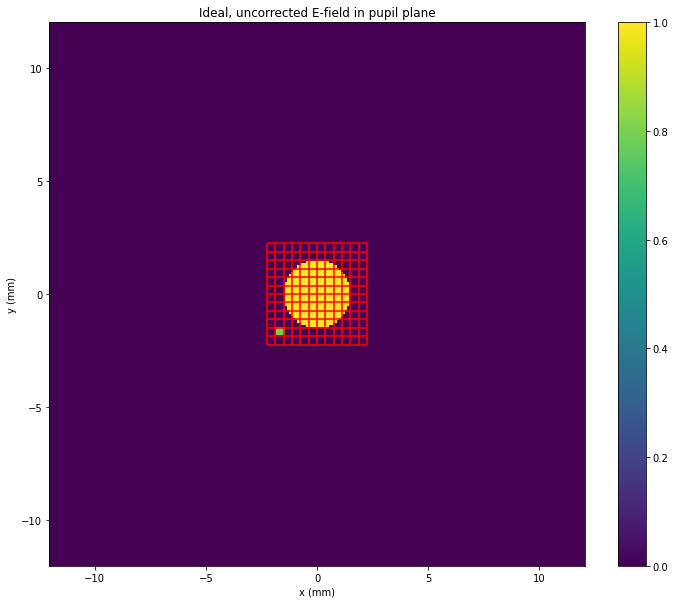

In [32]:
act_ID = 13

def actuator2pix(act_ID, DM_num_x, pupil_mid, actuator_sample):
    ''' Determines indices of pixels in pupil plane that correspond to a given actuator (ID-ed by zero-indexing).
        Inputs:
        - act_ID: integer, ID of a given actuator
        - DM_num_x: integer, number of actuators along the x-direction of the DM
        - pupil_mid: integer, index of DM origin (middle pixel in x- and y- direction)
        - actuator_sample: integer, oversampling rate of a given actuator
        Outputs:
        - row_min, row_max, col_min, col_max: indices bounding pixels corresponding to actuator
    
    '''
    row = int(np.floor(act_ID/DM_num_x))
    col = act_ID % DM_num_x
    row_min = int(pupil_mid + (row - DM_num_x/2)*actuator_sample)
    row_max = int(row_min + actuator_sample)
    col_min = int(pupil_mid + (col - DM_num_x/2)*actuator_sample)
    col_max = int(col_min + actuator_sample)
    return row_min, row_max, col_min, col_max

row_min, row_max, col_min, col_max = 

A = np.zeros((N+1, N+1))
A[(pupil_grid_x**2 + pupil_grid_y**2) < beam_rad**2] = 1 # Circular aperture
A[row_min:row_max, col_min:col_max] = 0.8

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
vrange = [np.min(np.absolute(A)), np.max(np.absolute(A))]
im = ax.pcolormesh(pupil_x.value, pupil_y.value, np.absolute(A), vmin=vrange[0], vmax=vrange[1])
ax.hlines(DM_edges_y.value, -DM_dim_x.value/2, DM_dim_x.value/2, color='r')
ax.vlines(DM_edges_x.value, -DM_dim_y.value/2, DM_dim_y.value/2, color='r')
ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_title('Ideal, uncorrected E-field in pupil plane')
fig.colorbar(im, ax=ax)
plt.show()

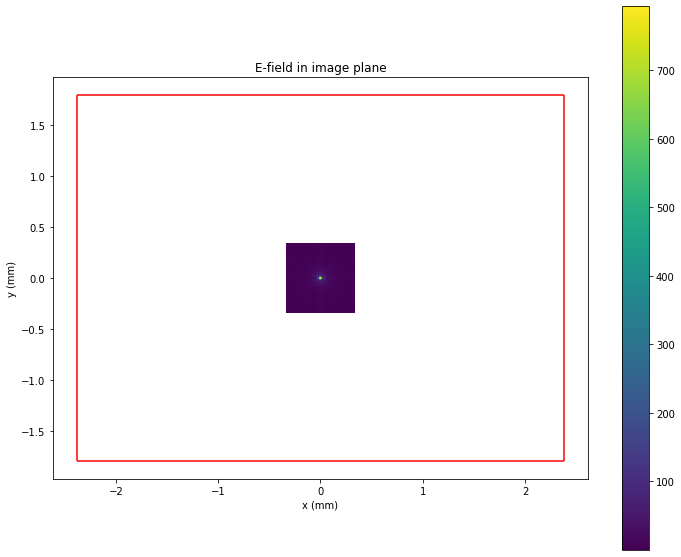

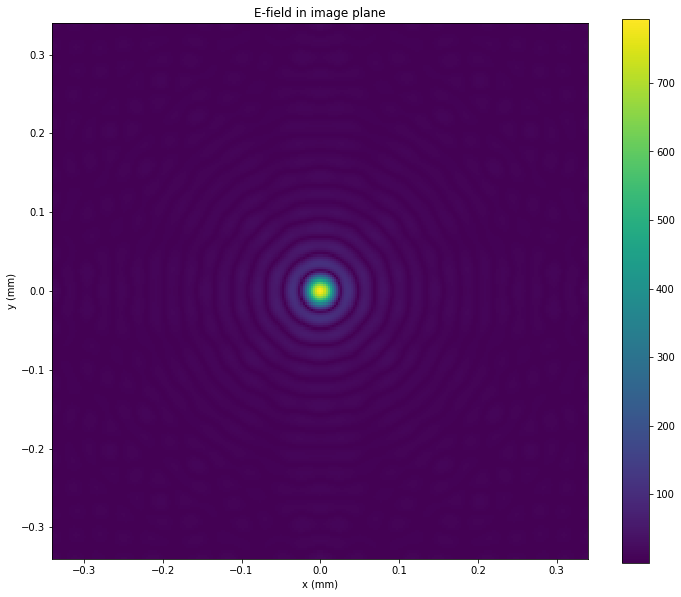

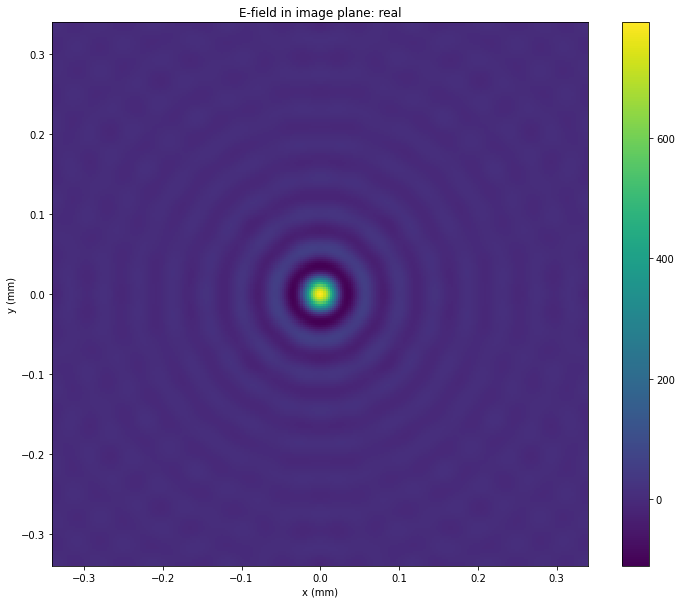

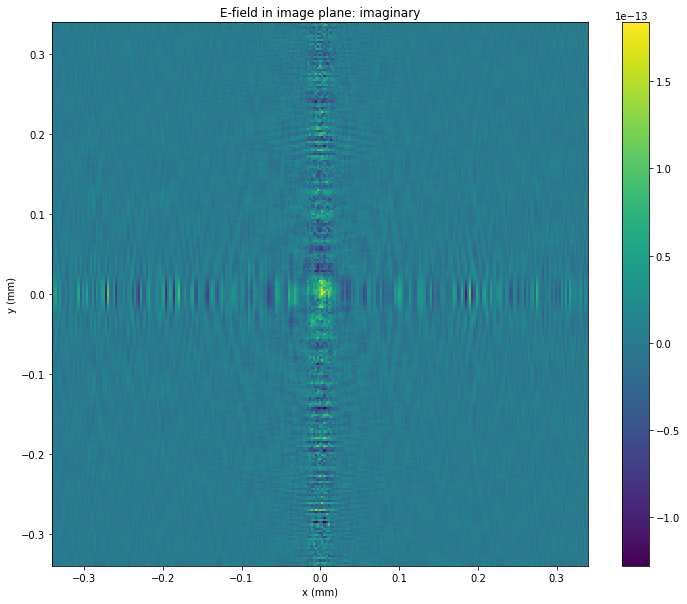

In [9]:
E_DM = C(A, pupil_x, pupil_y)
X = f * (wav_0.to(u.mm)/beam_diam.to(u.mm)) * (beam_diam.to(u.mm)/pupil_dim_x.to(u.mm)) * np.linspace(-N/2, N/2, N+1)
Y = f * (wav_0.to(u.mm)/beam_diam.to(u.mm)) * (beam_diam.to(u.mm)/pupil_dim_y.to(u.mm)) * np.linspace(-N/2, N/2, N+1)
X, Y = np.meshgrid(X.to(u.mm), Y.to(u.mm))

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
ax.set_aspect(1)
vrange = [np.min(np.absolute(E_DM)), np.max(np.absolute(E_DM))]
im = ax.pcolormesh(X.value, Y.value, np.absolute(E_DM), vmin=vrange[0], vmax=vrange[1])
ax.hlines([cam_edges_y[0].value, cam_edges_y[-1].value], -cam_dim_x.value/2, cam_dim_x.value/2, color='r')
ax.vlines([cam_edges_x[0].value, cam_edges_x[-1].value], -cam_dim_y.value/2, cam_dim_y.value/2, color='r')
ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_title('E-field in image plane')
fig.colorbar(im, ax=ax)
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
ax.set_aspect(1)
vrange = [np.min(np.absolute(E_DM)), np.max(np.absolute(E_DM))]
im = ax.pcolormesh(X.value, Y.value, np.absolute(E_DM), vmin=vrange[0], vmax=vrange[1])
ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_title('E-field in image plane')
fig.colorbar(im, ax=ax)
plt.show()


fig, ax = plt.subplots(1, 1, figsize=(12, 10))
vrange = [0, np.max(np.absolute(E_DM))]
im = ax.pcolormesh(X.value, Y.value, np.real(E_DM))
ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_title('E-field in image plane: real')
fig.colorbar(im, ax=ax)
plt.show()


fig, ax = plt.subplots(1, 1, figsize=(12, 10))
vrange = [0, np.max(np.absolute(E_DM))]
im = ax.pcolormesh(X.value, Y.value, np.imag(E_DM))
ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_title('E-field in image plane: imaginary')
fig.colorbar(im, ax=ax)
plt.show()

# Build DM matrix transformation

TypeError: Dimensions of C (257, 257) are incompatible with X (12) and/or Y (12); see help(pcolormesh)

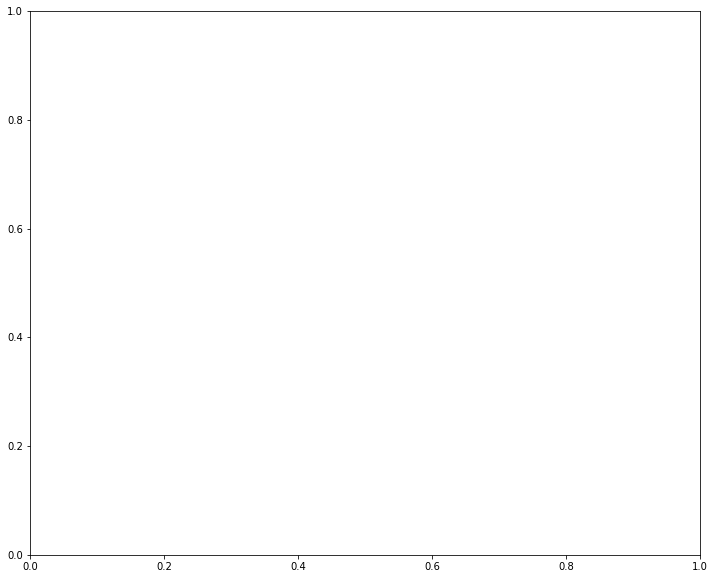

In [130]:
import matplotlib.colors as colors

DM_psi = np.zeros_like(A)
stroke = 0.01
# DM_psi[7, 4] = 2. * np.pi * (stroke * DM_stroke/wav_0)
DM_psi = A #* (2. * np.pi * (stroke * DM_stroke/wav_0))

E_DM = C(A * DM_psi, DM_ax_x, DM_ax_y)
X = f * (wav_0.to(u.mm)/DM_pix_x.to(u.mm)) * (beam_diam/DM_dim_x) * np.linspace(-DM_num_x/2., DM_num_x/2., DM_num_x+1)
Y = f * (wav_0.to(u.mm)/DM_pix_y.to(u.mm)) * (beam_diam/DM_dim_y) * np.linspace(-DM_num_y/2., DM_num_y/2., DM_num_y+1)
X, Y = np.meshgrid(X.to(u.mm), Y.to(u.mm))#*(beam_diam/DM_dim_x)


fig, ax = plt.subplots(1, 1, figsize=(12, 10))
im = ax.pcolormesh(DM_ax_x.value, DM_ax_y.value, DM_psi)#, vmin=vrange[0], vmax=vrange[1])
ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_title('DM configuration')
fig.colorbar(im, ax=ax)
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
vrange = [np.min(np.absolute(E_DM)), np.max(np.absolute(E_DM))]
im = ax.pcolormesh(X.value, Y.value, np.absolute(E_DM), vmin=vrange[0], vmax=vrange[1])
ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_title('DM transformation')
fig.colorbar(im, ax=ax)
plt.show()


fig, ax = plt.subplots(1, 1, figsize=(12, 10))
vrange = [0, np.max(np.absolute(E_DM))]
im = ax.pcolormesh(X.value, Y.value, np.real(E_DM))
ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_title('DM transformation: real')
fig.colorbar(im, ax=ax)
plt.show()


fig, ax = plt.subplots(1, 1, figsize=(12, 10))
vrange = [0, np.max(np.absolute(E_DM))]
im = ax.pcolormesh(X.value, Y.value, np.imag(E_DM))
ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_title('DM transformation: imaginary')
fig.colorbar(im, ax=ax)
plt.show()

# Interpolate to camera detector

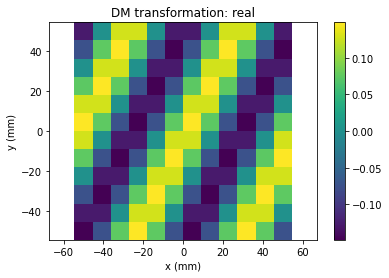

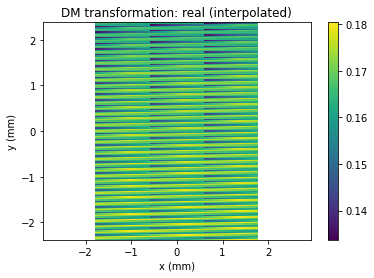

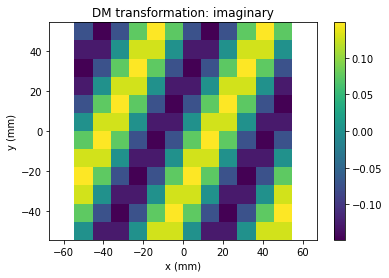

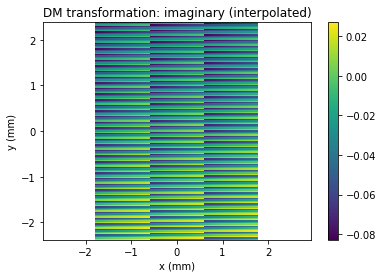

In [72]:
import scipy.interpolate

func_real = scipy.interpolate.interp2d(X.value, Y.value, np.real(E_DM))
func_imag = scipy.interpolate.interp2d(X.value, Y.value, np.imag(E_DM))
# E_DM_interp_real, E_DM_interp_imag = func_real(cam_x.value.flatten(), 
#                                                cam_y.value.flatten()), func_imag(cam_x.value.flatten(), 
#                                                                                  cam_y.value.flatten())

E_DM_interp_real, E_DM_interp_imag = func_real(cam_ax_x.value, 
                                               cam_ax_y.value), func_imag(cam_ax_x.value, 
                                                                       cam_ax_y.value)
E_DM_interp = E_DM_interp_real + 1j*E_DM_interp_imag
E_DM_interp = E_DM_interp.reshape(cam_num_x, cam_num_y)

fig, ax = plt.subplots(1, 1)
vrange = [0, np.max(np.absolute(E_DM))]
im = ax.pcolormesh(X.value, Y.value, np.real(E_DM))
ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_title('DM transformation: real')
ax.set_xlim(-cam_dim_x.value/2., cam_dim_x.value/2.)
ax.set_ylim(-cam_dim_y.value/2., cam_dim_y.value/2.)
fig.colorbar(im, ax=ax)
plt.axis('equal')
plt.show()

fig, ax = plt.subplots(1, 1)
vrange = [0, np.max(np.absolute(E_DM))]
im = ax.pcolormesh(cam_ax_y.value, cam_ax_x.value, np.real(E_DM_interp))
ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_title('DM transformation: real (interpolated)')
fig.colorbar(im, ax=ax)
plt.axis('equal')
plt.show()


fig, ax = plt.subplots(1, 1)
vrange = [0, np.max(np.absolute(E_DM))]
im = ax.pcolormesh(X.value, Y.value, np.imag(E_DM))
ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_title('DM transformation: imaginary')
plt.xlim(-cam_dim_x.value/2., cam_dim_x.value/2.)
plt.ylim(-cam_dim_y.value/2., cam_dim_y.value/2.)
fig.colorbar(im, ax=ax)
plt.axis('equal')
plt.show()

fig, ax = plt.subplots(1, 1)
vrange = [0, np.max(np.absolute(E_DM))]
im = ax.pcolormesh(cam_ax_y.value, cam_ax_x.value, np.imag(E_DM_interp))
ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_title('DM transformation: imaginary (interpolated)')
fig.colorbar(im, ax=ax)
plt.axis('equal')
plt.show()

# Transform to image plane

/home/paiasnodkar.1/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:63: RuntimeWarning: invalid value encountered in true_divide
/home/paiasnodkar.1/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:64: RuntimeWarning: invalid value encountered in true_divide


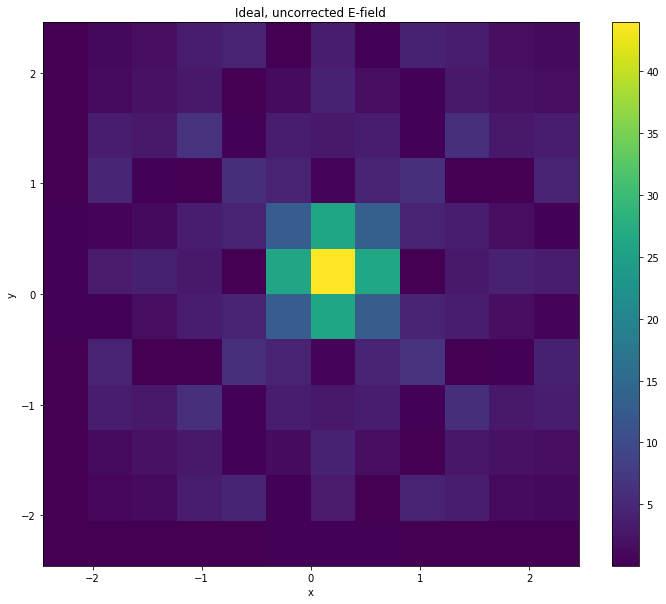

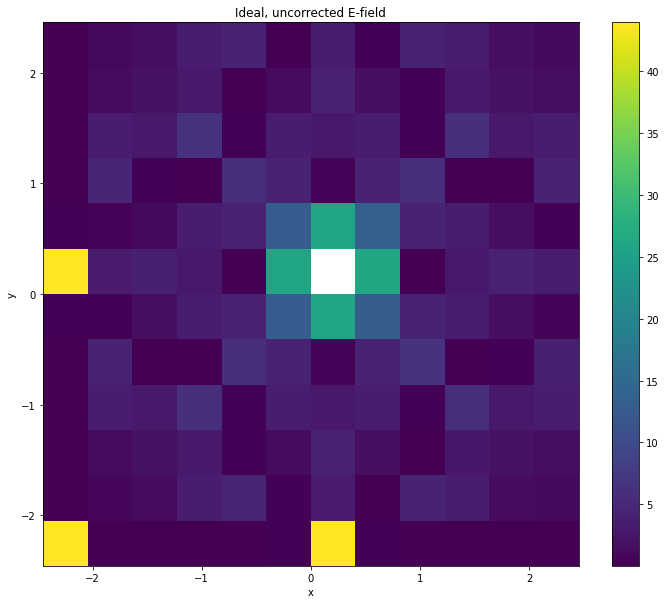

In [64]:
E_ab, X, Y = C(A * A_aber(alpha, beta), DM_ax_x, DM_ax_y, return_freq=True)
DM_factor = 1e-6
psi_1, psi_2 = np.random.rand(*np.shape(A)) * 2*np.pi * DM_factor, np.random.rand(*np.shape(A)) * 2*np.pi * DM_factor

# Generate corresponding difference images
I_diff_1, DM_real_1, DM_imag_1, X_samples, Y_samples = DM_image_diff(psi_1, E_ab, A, x_samples, y_samples)
I_diff_2, DM_real_2, DM_imag_2, X_samples, Y_samples = DM_image_diff(psi_2, E_ab, A, x_samples, y_samples)
X_samples, Y_samples = (X_samples * (wav_0 * d)).to(u.mm), (Y_samples * (wav_0 * d)).to(u.mm)

# Conduct EFC
E_ab_real, E_ab_imag = EFC(I_diff_1, DM_real_1, DM_imag_1, I_diff_2, DM_real_2, DM_imag_2)
E_ab_EFC = E_ab_real + 1j*E_ab_imag

# DM_image_diff(psi_pos, E_ab, A, x_samples, y_samples)
# EFC(I_diff_1, DM_real_1, DM_imag_1, I_diff_2, DM_real_2, DM_imag_2)

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
vrange = [np.min(np.absolute(E_ab)), np.max(np.absolute(E_ab))]
im = ax.pcolormesh(DM_ax_x.value, DM_ax_y.value, np.absolute(E_ab), vmin=vrange[0], vmax=vrange[1])
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Ideal, uncorrected E-field')
fig.colorbar(im, ax=ax)
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
vrange = [np.min(np.absolute(E_ab)), np.max(np.absolute(E_ab))]
im = ax.pcolormesh(DM_ax_x.value, DM_ax_y.value, np.absolute(E_ab_EFC), vmin=vrange[0], vmax=vrange[1])
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Ideal, uncorrected E-field')
fig.colorbar(im, ax=ax)
plt.show()